In [44]:
import os
import rasterio as rio
import numpy as np
import pandas as pd


from spectral import envi
import matplotlib.pyplot as plt
import matplotlib.path as pth
from pathlib import Path

from scipy.ndimage import binary_erosion
from pyproj import Transformer

import shapefile as shp

import Functions
import importlib

importlib.reload(Functions)

<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [45]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'

sentinel_path = Path('/media')/ 'frank' / 'USB' / 'SCUOLA' / 'App' / 'BACKSCATTER'

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [46]:
img_dates = Functions.read_dates_from_stack(sentinel_path)

shapes = list(shape_path.glob('*.shp'))
hdrs = list(sentinel_path.glob('*.hdr'))
print(np.count_nonzero(img_dates))
#print(img_dates)

59


Estraggo i poligoni dei campi

In [47]:
mypoly = { }


for file in shapes:

    file_stem = Path(file).stem
    poly = Functions.open_shp(file)

    if poly is not None:
        
        poly_utm_list = Functions.cambio_coord(poly)
        
        mypoly[file_stem] = {
            'coord': poly_utm_list, # Salva la lista di pezzi
            'path': [pth.Path(p) for p in poly_utm_list] # Lista di oggetti Path
        }
    else:
        print(f"Salto il file {file} perché non è valido.")
        
    #print(f"Il poligono ha {len(mypoly[file_stem]['coord'])} pezzi.")

print(len(mypoly.keys()))

27


LEGGO LE COORIDNATE SENTINEL: sono tutte uguali? controllare con SNAP
Creo la maschera (Vero-Falso) dei poligoni sulla immagine Sentinel

In [48]:
X_geo, Y_geo = Functions.axes_from_metadata(hdrs[0])

for key in mypoly:

    # 1. Trova il Bounding Box totale unendo tutti i pezzi del campo
    # Stack di tutti i pezzi per calcolare min/max globali

    all_coords = np.vstack(mypoly[key]['coord'])
    xmin, ymin = all_coords.min(axis=0)
    xmax, ymax = all_coords.max(axis=0)

    # 2. Trova gli indici nell'immagine Sentinel
    idx_x = np.where((X_geo >= xmin) & (X_geo <= xmax))[0]
    idx_y = np.where((Y_geo >= ymin) & (Y_geo <= ymax))[0]

    # 3. Crea la griglia di punti per il ritaglio (Subset)
    r0, r1 = idx_y.min(), idx_y.max() + 1
    c0, c1 = idx_x.min(), idx_x.max() + 1

    X_sub = X_geo[c0:c1]
    Y_sub = Y_geo[r0:r1]
    
    # 4. Creazione maschera migliorata
    X_grid, Y_grid = np.meshgrid(X_sub, Y_sub)
    # Importante: usiamo stack per avere coppie (x, y) pulite
    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

    mymask_sub = np.zeros(X_grid.shape, dtype=bool)
    # Cicla su ogni oggetto Path nella lista salvata precedentemente
    for pth_obj in mypoly[key]['path']:
        # Crea la maschera per il singolo pezzo e uniscila con l'OR logico (|)
        # Usiamo order='C' (standard) e poi .reshape()
        current_part_mask = pth_obj.contains_points(points).reshape(X_grid.shape)
        mymask_sub |= current_part_mask

    mask_eroted = binary_erosion(mymask_sub, structure=np.ones((3,3))).astype(mymask_sub.dtype)
    mypoly[key]['mask_sub'] =  mask_eroted #mymask_sub  
    mypoly[key]['r_range'] = (r0, r1)
    mypoly[key]['c_range'] = (c0, c1)

# Debug finale
field = 'AKW-G1_C'
print(f"Indice colonna iniziale per {field}: {mypoly[field]['c_range'][0]}")
print(f"Shape della maschera erosa: {mypoly[field]['mask_sub'].shape}")

Indice colonna iniziale per AKW-G1_C: 5240
Shape della maschera erosa: (33, 35)


In [49]:
poly_stats = {k: {} for k in mypoly}

for file in hdrs:

    file_path = Path(file)
    file_stem = file_path.stem
    date = file_stem[:8] # Assumendo formato YYYYMMDD
    
    # 1. Apriamo il file (senza caricarlo in RAM!)
    img_obj = Functions.read_img2(file, '')

    # Determiniamo la polarizzazione dal nome del file
    pol = 'VH' if 'VH' in file_stem else 'VV'
    name = f'{date}_{pol}'

    print(f'Processing {pol} for date {date}...')

    for key in mypoly:
        r1, r2 = mypoly[key]['r_range']
        c1, c2 = mypoly[key]['c_range']
    
        # 2. LEGGIAMO SOLO IL RITAGLIO DAL DISCO
        # read_subregion( (r_start, r_end), (c_start, c_end) )
        radar_sub = img_obj.read_subregion((r1, r2), (c1, c2))
        
        # Pulizia dimensioni (da (H, W, 1) a (H, W))
        radar_sub = np.squeeze(radar_sub)
    
        # 3. Applichiamo la maschera erosa
        pixel_campo = radar_sub[mypoly[key]['mask_sub']]

        if len(pixel_campo) > 0:
            if name not in poly_stats[key]:
                poly_stats[key][name] = {}
            
            # Calcolo in lineare
            m_lin = np.mean(pixel_campo)
            s_lin = np.std(pixel_campo)
            
            # Salvataggio (puoi aggiungere anche la conversione in dB qui)
            poly_stats[key][name]['mean'] = m_lin
            poly_stats[key][name]['std'] = s_lin

        else:
            print(f"Attenzione: nessun pixel valido per {key} in {file_stem}")

# Pulizia manuale della memoria alla fine di ogni file (opzionale)

del img_obj

Processing VH for date 20170104...
Processing VV for date 20170104...
Processing VH for date 20170110...
Processing VV for date 20170110...
Processing VH for date 20170116...
Processing VV for date 20170116...
Processing VH for date 20170122...
Processing VV for date 20170122...
Processing VH for date 20170128...
Processing VV for date 20170128...
Processing VH for date 20170203...
Processing VV for date 20170203...
Processing VH for date 20170209...
Processing VV for date 20170209...
Processing VH for date 20170215...
Processing VV for date 20170215...
Processing VH for date 20170221...
Processing VV for date 20170221...
Processing VH for date 20170227...
Processing VV for date 20170227...
Processing VH for date 20170305...
Processing VV for date 20170305...
Processing VH for date 20170311...
Processing VV for date 20170311...
Processing VH for date 20170317...
Processing VV for date 20170317...
Processing VH for date 20170323...
Processing VV for date 20170323...
Processing VH for da

In [50]:
print(poly_stats['DB_A_C']['20170104_VV'])

{'mean': np.float32(-7.172247), 'std': np.float32(1.05917)}


Hya unas pequeñas diferencias entre los valores calculados con SNAP (y los shapefiles) ccon las calculadas aqui:
es: TK_MA_C: media = -16.6973

LEGGO IMMGAINE SAR e salvo i valori di media e std in un dizionario cosi organizzato:

poly_stats [poligono][data+VH o data+VV][media/std]

In [51]:
# poly_stats = {k: {} for k in mypoly }

# for file in hdrs:

#     file_stem = Path(file).stem

#     hdr, img = Functions.read_img(file,'')
#     date = file_stem[:8]

#     print(f'Reading image: {file_stem}')

#     for key in mypoly:

#         poly_stats[key]
#         r1, r2 = mypoly[key]['r_range']
#         c1, c2 = mypoly[key]['c_range']
    
#     # 2. Ritaglia l'immagine radar (Crop)
#     # Ora 'radar_sub' ha la stessa identica forma di 'mask_sub'
#         radar_sub = np.squeeze(img[r1:r2, c1:c2])
    
#     # 3. Applica la maschera piccola al ritaglio piccolo
#     # Estrae solo i pixel che appartengono al campo
#         pixel_campo = radar_sub[mypoly[key]['mask_sub']]

#         if file.glob('*VH'):
#             name = f'{date}_VH'
#             poly_stats[key][name] = {}
        
#         else:
#             name = f'{date}_VV'
#             poly_stats[key][name] = {}
        
#     # 4. Calcola la media (Sigma0)
#         poly_stats[key][name]['mean'] = np.mean(pixel_campo)
#         poly_stats[key][name]['std'] = np.std(pixel_campo)




CREO DATAFRAME CON LE STATISTICHE

In [52]:
rows = []
for roi, dates_dict in poly_stats.items():
    for date_band, stats in dates_dict.items():
        # Creiamo una riga con ROI, Data_Banda e tutte le statistiche (mean, std, ecc.)
        row = {'ROI': roi, 'Date_Band': date_band}
        row.update(stats) # Aggiunge 'mean', 'std', ecc. come colonne
        rows.append(row)

df_stats = pd.DataFrame(rows)

# Opzionale: Separa la data dalla banda se il formato è '20170104_VH'
df_stats[['Date', 'Band']] = df_stats['Date_Band'].str.split('_', expand=True)
df_stats['Date'] = pd.to_datetime(df_stats['Date'])

display(df_stats)

,ROI,Date_Band,mean,std,Date,Band
0,DB_A_C,20170104_VH,-14.988747,1.152336,2017-01-04,VH
1,DB_A_C,20170104_VV,-7.172247,1.059170,2017-01-04,VV
2,DB_A_C,20170110_VH,-13.919929,0.968011,2017-01-10,VH
3,DB_A_C,20170110_VV,-5.792219,0.991691,2017-01-10,VV
4,DB_A_C,20170116_VH,-20.690327,1.066293,2017-01-16,VH
...,...,...,...,...,...,...
3181,DB_SB1_C,20171218_VV,-5.278055,1.091359,2017-12-18,VV
3182,DB_SB1_C,20171224_VH,-13.429222,0.918860,2017-12-24,VH
3183,DB_SB1_C,20171224_VV,-5.429169,1.148561,2017-12-24,VV
3184,DB_SB1_C,20171230_VH,-12.458362,0.862726,2017-12-30,VH


Visualizzo la maschera sull'immagine

In [53]:
print(poly_stats['KL_MA_1_C']['20170305_VV']['mean'])


-11.187754


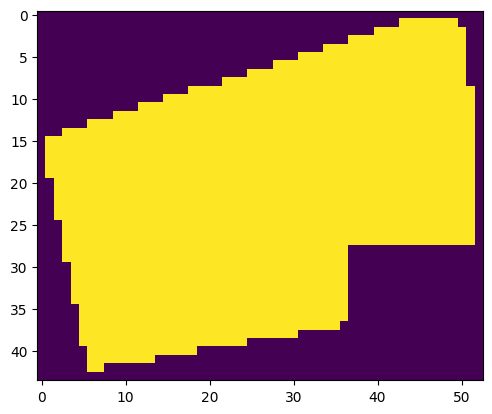

In [54]:
plt.imshow(mypoly['DB_A_C']['mask_sub'])

(6346, 7025)



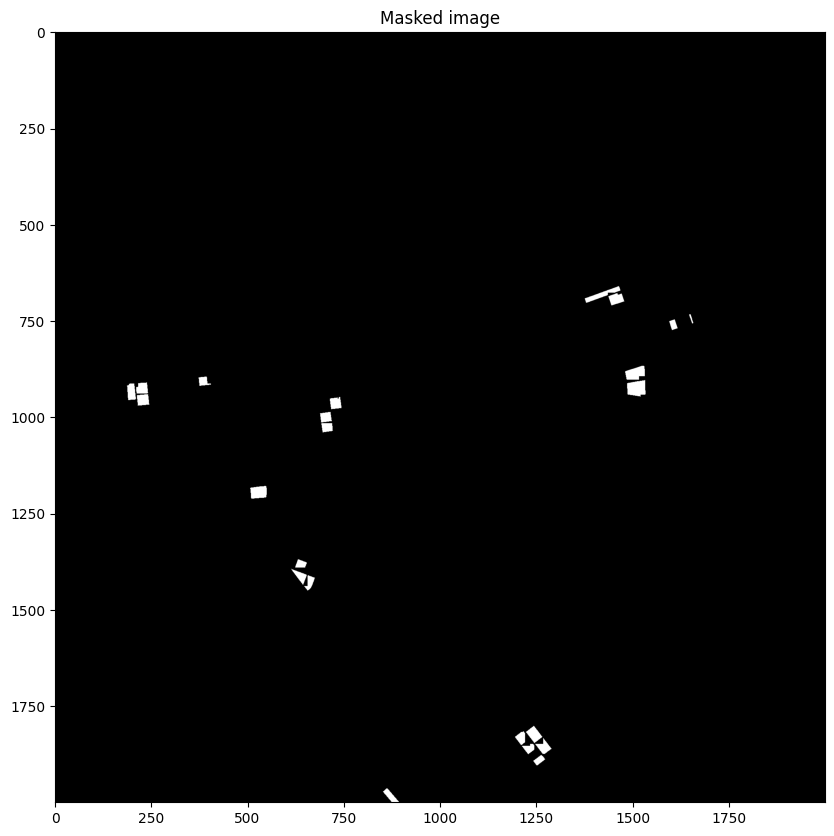

In [55]:
full_mask = np.zeros((len(Y_geo), len(X_geo)), dtype=bool)
print(full_mask.shape)

_ , IMG = Functions.read_img(hdrs[0],'')

# 2. Inserisci la maschera piccola nella posizione corretta usando gli indici
# idx_y e idx_x definiscono le "coordinate matriciali" in cui incollare il pezzo
print()
for i in mypoly:

    full_mask[mypoly[i]['r_range'][0]:mypoly[i]['r_range'][1], 
              mypoly[i]['c_range'][0]:mypoly[i]['c_range'][1]] = mypoly[i]['mask_sub']

plt.figure(figsize=(10,10))
plt.imshow(full_mask[1000:3000,4000:6000], cmap='gray')
plt.title("Masked image")
plt.show()

In [56]:
new = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Name_Type.csv'
Nme_types = pd.read_csv(new, header=0)
df_stats = df_stats.merge(Nme_types, on='ROI', how='left')
display(df_stats)


,ROI,Date_Band,mean,std,Date,Band,Type
0,DB_A_C,20170104_VH,-14.988747,1.152336,2017-01-04,VH,Aardappelen
1,DB_A_C,20170104_VV,-7.172247,1.059170,2017-01-04,VV,Aardappelen
2,DB_A_C,20170110_VH,-13.919929,0.968011,2017-01-10,VH,Aardappelen
3,DB_A_C,20170110_VV,-5.792219,0.991691,2017-01-10,VV,Aardappelen
4,DB_A_C,20170116_VH,-20.690327,1.066293,2017-01-16,VH,Aardappelen
...,...,...,...,...,...,...,...
3181,DB_SB1_C,20171218_VV,-5.278055,1.091359,2017-12-18,VV,Bieten
3182,DB_SB1_C,20171224_VH,-13.429222,0.918860,2017-12-24,VH,Bieten
3183,DB_SB1_C,20171224_VV,-5.429169,1.148561,2017-12-24,VV,Bieten
3184,DB_SB1_C,20171230_VH,-12.458362,0.862726,2017-12-30,VH,Bieten


In [58]:
df_stats.to_csv('TimeSeries_sigma.csv', index=False)

GRAFICI DELLE STATISTICHE

In [57]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = app_path / 'Documents'
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Time_Series_ROI_BACKSCATTER.pdf'

with PdfPages(pdf_filename) as pdf:
    unique_rois = df_stats['ROI'].unique()

    for roi in unique_rois:
        # Crea la figura
        plt.figure(figsize=(12, 6))
        roi_data = df_stats[df_stats['ROI'] == roi]
        
        for band in roi_data['Band'].unique():
            band_data = roi_data[roi_data['Band'] == band]
            
            # Plot della linea media
            line, = plt.plot(band_data['Date'], band_data['mean'], 
                             marker='o', linestyle='-', linewidth=2, label=f'Mean {band}')
            
            # Area della deviazione standard (Mean ± Std) con rf'' per LaTeX
            plt.fill_between(
                band_data['Date'], 
                band_data['mean'] - band_data['std'], 
                band_data['mean'] + band_data['std'], 
                color=line.get_color(), 
                alpha=0.15, 
                label=rf'Dispersion $\pm 1\sigma$ ({band})'
            )

        # Formattazione estetica
        plt.title(f"Time Series ROI: {roi}", fontsize=14, fontweight='bold')
        plt.xlabel("Data", fontsize=12)
        plt.ylabel("Value (Reflectance / Backscatter)", fontsize=12)
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Legenda fuori dal grafico
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        pdf.savefig()
        
        plt.close()

print(f"Done! All graphs had been saved in : {pdf_filename}")


Done! All graphs had been saved in : /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/Time_Series_ROI_BACKSCATTER.pdf
